In [21]:
import os
import torch
import torch.nn as nn
import numpy as np
from tqdm.notebook import trange, tqdm
import h5py
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import glob
from torch.utils.data import TensorDataset, random_split, DataLoader
from sklearn.metrics import f1_score, average_precision_score

## Data Analysis


Chunk # 0 >> number of pos. examples >> 404
>> weight >> 48.504950495049506
torch.Size([20000, 4096, 12]) torch.Size([20000, 1])
at 0  >> 50%
Number of female patients 12013
of which positive for AF -- 191
Number of male patients 7987
of which positive for AF -- 213

----Age Distribution----



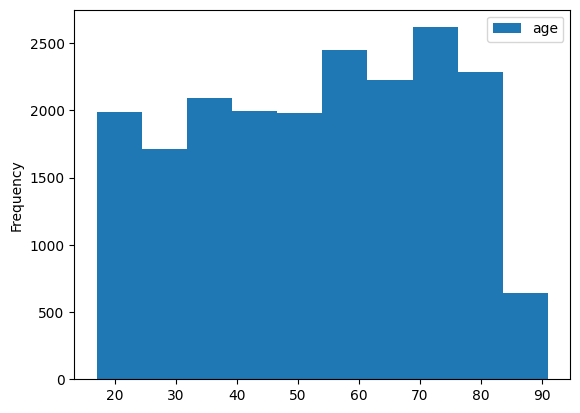


Chunk # 1 >> number of pos. examples >> 446
>> weight >> 43.84304932735426
torch.Size([20000, 4096, 12]) torch.Size([20000, 1])
at 1  >> 50%
Number of female patients 12071
of which positive for AF -- 213
Number of male patients 7929
of which positive for AF -- 233

----Age Distribution----



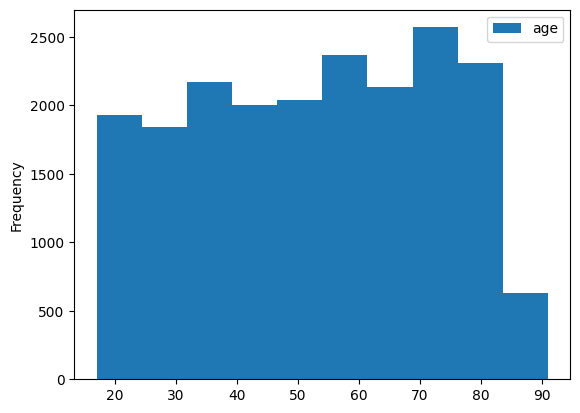


Chunk # 2 >> number of pos. examples >> 405
>> weight >> 48.382716049382715
torch.Size([20000, 4096, 12]) torch.Size([20000, 1])
at 2  >> 50%
Number of female patients 11902
of which positive for AF -- 191
Number of male patients 8098
of which positive for AF -- 214

----Age Distribution----



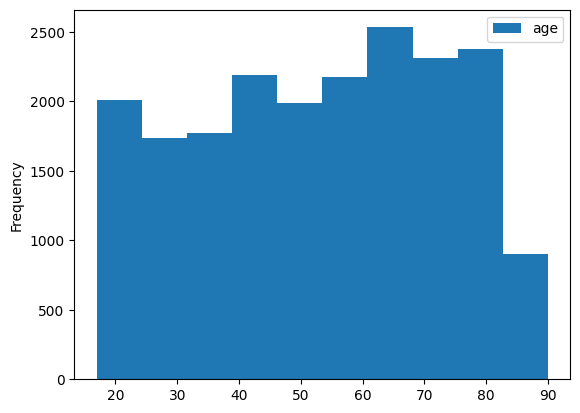


Chunk # 3 >> number of pos. examples >> 415
>> weight >> 47.19277108433735
torch.Size([20000, 4096, 12]) torch.Size([20000, 1])
at 3  >> 50%
Number of female patients 11851
of which positive for AF -- 187
Number of male patients 8149
of which positive for AF -- 228

----Age Distribution----



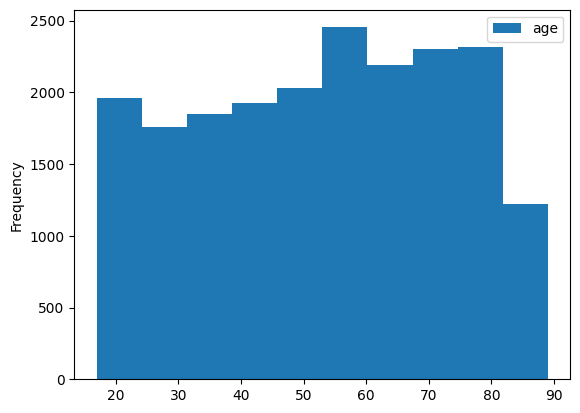


Chunk # 4 >> number of pos. examples >> 380
>> weight >> 51.63157894736842
torch.Size([20000, 4096, 12]) torch.Size([20000, 1])
at 4  >> 50%
Number of female patients 11963
of which positive for AF -- 168
Number of male patients 8037
of which positive for AF -- 212

----Age Distribution----



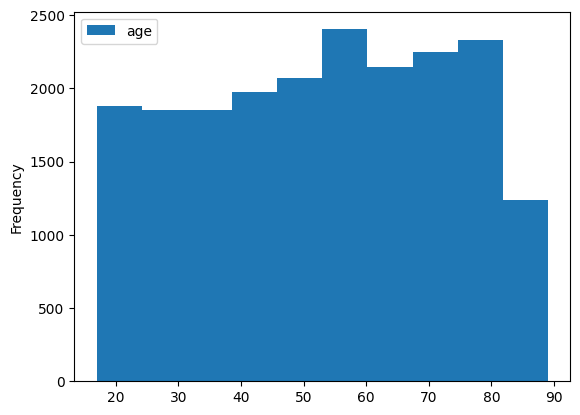


Chunk # 5 >> number of pos. examples >> 381
>> weight >> 51.493438320209975
torch.Size([20000, 4096, 12]) torch.Size([20000, 1])
at 5  >> 50%
Number of female patients 11895
of which positive for AF -- 177
Number of male patients 8105
of which positive for AF -- 204

----Age Distribution----



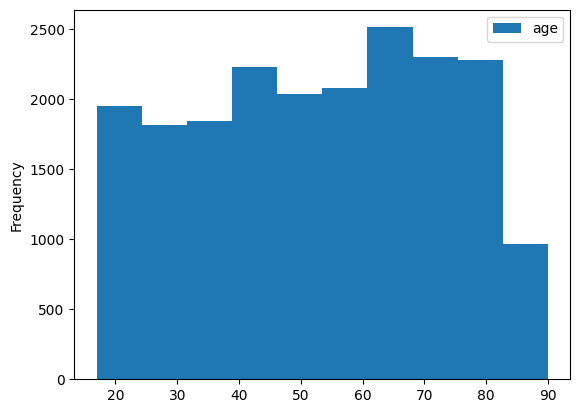


Chunk # 6 >> number of pos. examples >> 421
>> weight >> 46.50593824228029
torch.Size([20000, 4096, 12]) torch.Size([20000, 1])
at 6  >> 50%
Number of female patients 11997
of which positive for AF -- 192
Number of male patients 8003
of which positive for AF -- 229

----Age Distribution----



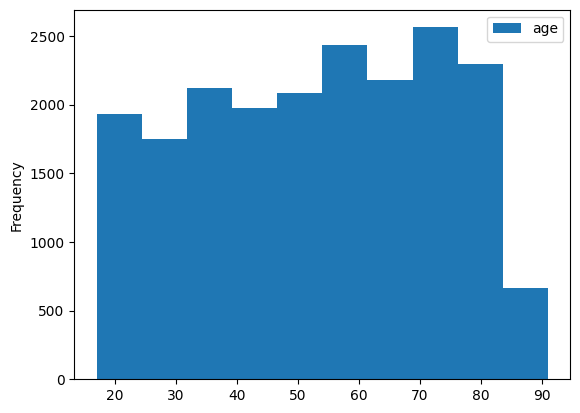


Chunk # 7 >> number of pos. examples >> 372
>> weight >> 52.763440860215056
torch.Size([20000, 4096, 12]) torch.Size([20000, 1])
at 7  >> 50%
Number of female patients 11935
of which positive for AF -- 163
Number of male patients 8065
of which positive for AF -- 209

----Age Distribution----



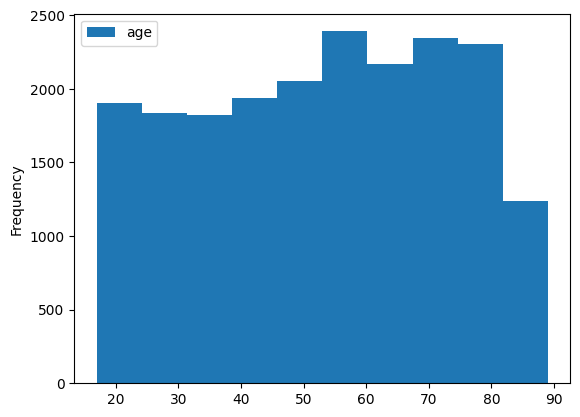


Chunk # 8 >> number of pos. examples >> 378
>> weight >> 51.91005291005291
torch.Size([20000, 4096, 12]) torch.Size([20000, 1])
at 8  >> 50%
Number of female patients 11920
of which positive for AF -- 177
Number of male patients 8080
of which positive for AF -- 201

----Age Distribution----



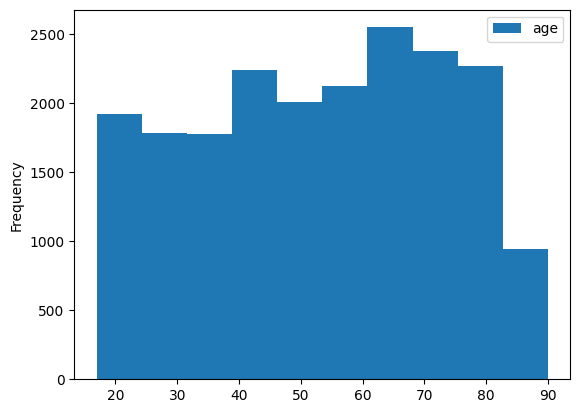


Chunk # 9 >> number of pos. examples >> 414
>> weight >> 47.309178743961354
torch.Size([20000, 4096, 12]) torch.Size([20000, 1])
at 9  >> 50%
Number of female patients 11917
of which positive for AF -- 196
Number of male patients 8083
of which positive for AF -- 218

----Age Distribution----



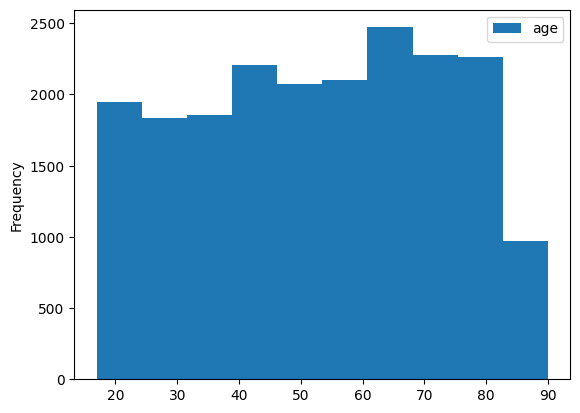


Chunk # 10 >> number of pos. examples >> 392
>> weight >> 50.02040816326531
torch.Size([20000, 4096, 12]) torch.Size([20000, 1])
at 10  >> 50%
Number of female patients 11874
of which positive for AF -- 188
Number of male patients 8126
of which positive for AF -- 204

----Age Distribution----



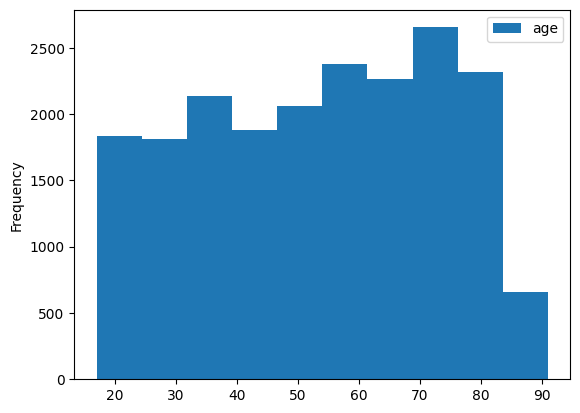


Chunk # 11 >> number of pos. examples >> 368
>> weight >> 53.34782608695652
torch.Size([20000, 4096, 12]) torch.Size([20000, 1])
at 11  >> 50%
Number of female patients 11821
of which positive for AF -- 162
Number of male patients 8179
of which positive for AF -- 206

----Age Distribution----



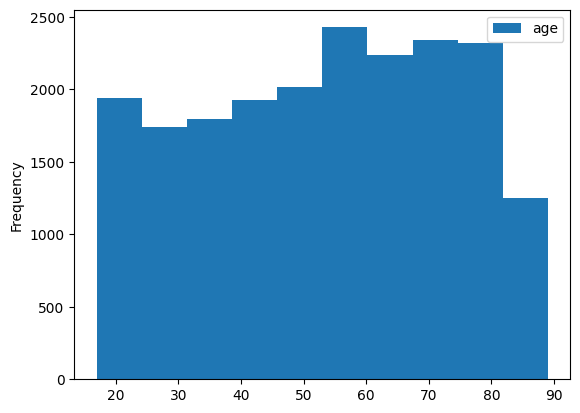


Chunk # 12 >> number of pos. examples >> 412
>> weight >> 47.54368932038835
torch.Size([20000, 4096, 12]) torch.Size([20000, 1])
at 12  >> 50%
Number of female patients 11911
of which positive for AF -- 168
Number of male patients 8089
of which positive for AF -- 244

----Age Distribution----



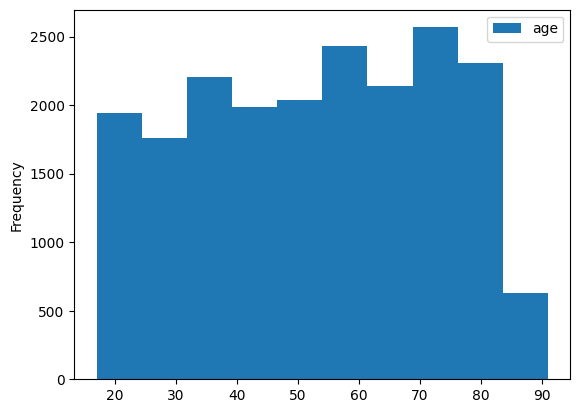


Chunk # 13 >> number of pos. examples >> 385
>> weight >> 50.94805194805195
torch.Size([20000, 4096, 12]) torch.Size([20000, 1])
at 13  >> 50%
Number of female patients 11969
of which positive for AF -- 169
Number of male patients 8031
of which positive for AF -- 216

----Age Distribution----



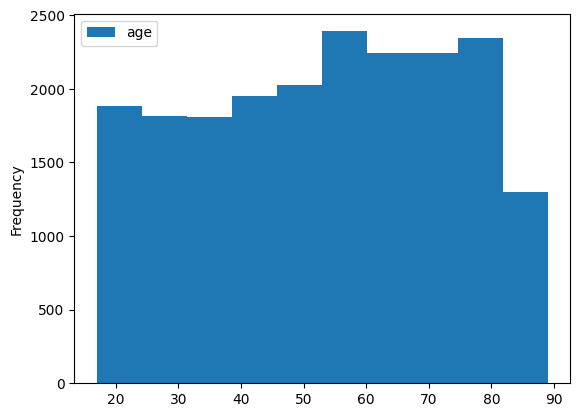


Chunk # 14 >> number of pos. examples >> 445
>> weight >> 43.943820224719104
torch.Size([20000, 4096, 12]) torch.Size([20000, 1])
at 14  >> 50%
Number of female patients 12138
of which positive for AF -- 208
Number of male patients 7862
of which positive for AF -- 237

----Age Distribution----



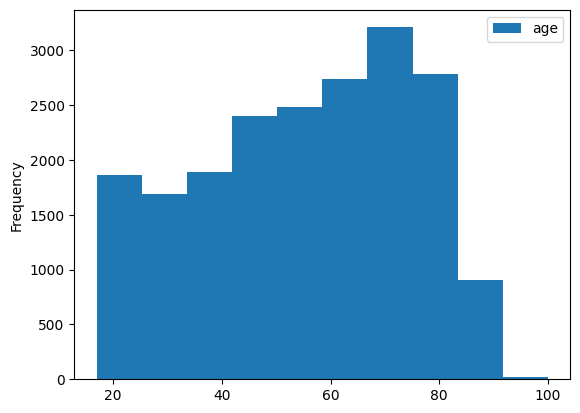


Chunk # 15 >> number of pos. examples >> 438
>> weight >> 44.662100456621005
torch.Size([20000, 4096, 12]) torch.Size([20000, 1])
at 15  >> 50%
Number of female patients 12006
of which positive for AF -- 204
Number of male patients 7994
of which positive for AF -- 234

----Age Distribution----



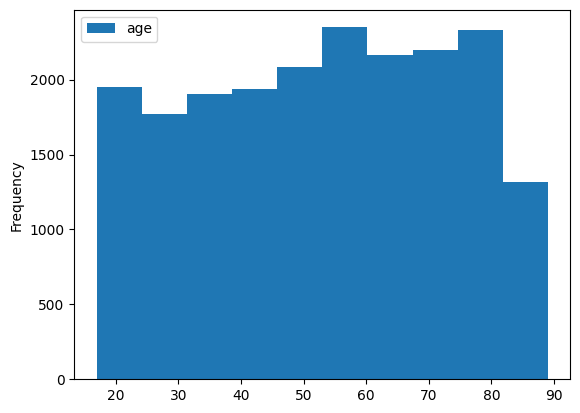


Chunk # 16 >> number of pos. examples >> 417
>> weight >> 46.961630695443645
torch.Size([20000, 4096, 12]) torch.Size([20000, 1])
at 16  >> 50%
Number of female patients 11967
of which positive for AF -- 201
Number of male patients 8033
of which positive for AF -- 216

----Age Distribution----



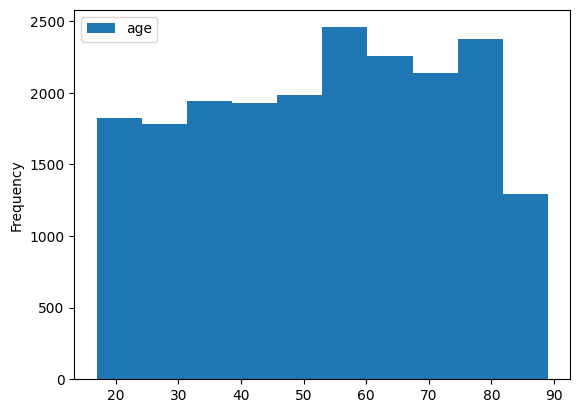

In [67]:
for i, filepath in enumerate(glob.glob("data/code15-12l/*.hdf5")):
    prefix = filepath.replace("data/code15-12l/", "").replace(".hdf5", "")
    path_to_h5_train, path_to_csv_train = filepath, 'data/code15-12l/exams.csv' # path_to_records = 'data/codesubset/RECORDS.txt'
    
    # load traces
    f = h5py.File(path_to_h5_train, 'r')
    traces = torch.tensor(f['tracings'][()], dtype=torch.float32)[:-1,:,:]
    
    # load labels
    ids_traces = np.array(f['exam_id'])
    df = pd.read_csv(path_to_csv_train)
    df.set_index('exam_id', inplace=True)
    df = df.reindex(ids_traces).dropna(subset=["AF"]) # make sure the order is the same, last entry removed as a nan row is created in the reindexing
    labels = torch.tensor(np.array(df['AF'], dtype=np.float32), dtype=torch.float32, device=device).reshape(-1,1)
    print("\nChunk #", i, ">> number of pos. examples >>", len(df[df['AF']==1]))
    print(">> weight >>", len(df[df['AF']==0])/len(df[df['AF']==1]))
    print(traces.size(), labels.size())
    print("at", i, " >> 50%")

    #### CHECK THE BALANCE
    # Number of female patients 
    print("Number of female patients", len(df[df['is_male'] == 0]))
    females = df[df['is_male'] == 0]
    print("of which positive for AF --", len(females[females['AF']==1]))
    # Number of male patients
    print("Number of male patients", len(df[df['is_male'] == 1]))
    males = df[df['is_male'] == 1]
    print("of which positive for AF --", len(males[males['AF']==1]))
    
    #### SEE HOW IT IS DISTRIBUTED ACROSS GENDERS/AGES
    print("\n----Age Distribution----\n")
    ax = df.plot.hist(column=['age'], bins=10)
    plt.show()

## Training

In [60]:
def _padding(downsample, kernel_size):
    """Compute required padding"""
    padding = max(0, int(np.floor((kernel_size - downsample + 1) / 2)))
    return padding


def _downsample(n_samples_in, n_samples_out):
    """Compute downsample rate"""
    downsample = int(n_samples_in // n_samples_out)
    if downsample < 1:
        raise ValueError("Number of samples should always decrease")
    if n_samples_in % n_samples_out != 0:
        raise ValueError("Number of samples for two consecutive blocks "
                         "should always decrease by an integer factor.")
    return downsample


class ResBlock1d(nn.Module):
    """Residual network unit for unidimensional signals."""

    def __init__(self, n_filters_in, n_filters_out, downsample, kernel_size, dropout_rate):
        if kernel_size % 2 == 0:
            raise ValueError("The current implementation only support odd values for `kernel_size`.")
        super(ResBlock1d, self).__init__()
        # Forward path
        padding = _padding(1, kernel_size)
        self.conv1 = nn.Conv1d(n_filters_in, n_filters_out, kernel_size, padding=padding, bias=False)
        self.bn1 = nn.BatchNorm1d(n_filters_out)
        self.relu = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_rate)
        padding = _padding(downsample, kernel_size)
        self.conv2 = nn.Conv1d(n_filters_out, n_filters_out, kernel_size,
                               stride=downsample, padding=padding, bias=False)
        self.bn2 = nn.BatchNorm1d(n_filters_out)
        self.dropout2 = nn.Dropout(dropout_rate)

        # Skip connection
        skip_connection_layers = []
        # Deal with downsampling
        if downsample > 1:
            maxpool = nn.MaxPool1d(downsample, stride=downsample)
            skip_connection_layers += [maxpool]
        # Deal with n_filters dimension increase
        if n_filters_in != n_filters_out:
            conv1x1 = nn.Conv1d(n_filters_in, n_filters_out, 1, bias=False)
            skip_connection_layers += [conv1x1]
        # Build skip conection layer
        if skip_connection_layers:
            self.skip_connection = nn.Sequential(*skip_connection_layers)
        else:
            self.skip_connection = None

    def forward(self, x, y):
        """Residual unit."""
        if self.skip_connection is not None:
            y = self.skip_connection(y)
        else:
            y = y
        # 1st layer
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout1(x)

        # 2nd layer
        x = self.conv2(x)
        x += y  # Sum skip connection and main connection
        y = x
        x = self.bn2(x)
        x = self.relu(x)
        x = self.dropout2(x)
        return x, y


class ResNet1d(nn.Module):
    """Residual network for unidimensional signals.
    Parameters
    ----------
    input_dim : tuple
        Input dimensions. Tuple containing dimensions for the neural network
        input tensor. Should be like: ``(n_filters, n_samples)``.
    blocks_dim : list of tuples
        Dimensions of residual blocks.  The i-th tuple should contain the dimensions
        of the output (i-1)-th residual block and the input to the i-th residual
        block. Each tuple shoud be like: ``(n_filters, n_samples)``. `n_samples`
        for two consecutive samples should always decrease by an integer factor.
    dropout_rate: float [0, 1), optional
        Dropout rate used in all Dropout layers. Default is 0.8
    kernel_size: int, optional
        Kernel size for convolutional layers. The current implementation
        only supports odd kernel sizes. Default is 17.
    References
    ----------
    .. [1] K. He, X. Zhang, S. Ren, and J. Sun, "Identity Mappings in Deep Residual Networks,"
           arXiv:1603.05027, Mar. 2016. https://arxiv.org/pdf/1603.05027.pdf.
    .. [2] K. He, X. Zhang, S. Ren, and J. Sun, "Deep Residual Learning for Image Recognition," in 2016 IEEE Conference
           on Computer Vision and Pattern Recognition (CVPR), 2016, pp. 770-778. https://arxiv.org/pdf/1512.03385.pdf
    """

    def __init__(self, input_dim, blocks_dim, n_classes, kernel_size=17, dropout_rate=0.8):
        super(ResNet1d, self).__init__()
        # First layers
        n_filters_in, n_filters_out = input_dim[0], blocks_dim[0][0]
        n_samples_in, n_samples_out = input_dim[1], blocks_dim[0][1]
        downsample = _downsample(n_samples_in, n_samples_out)
        padding = _padding(downsample, kernel_size)
        self.conv1 = nn.Conv1d(n_filters_in, n_filters_out, kernel_size, bias=False,
                               stride=downsample, padding=padding)
        self.bn1 = nn.BatchNorm1d(n_filters_out)

        # Residual block layers
        self.res_blocks = []
        for i, (n_filters, n_samples) in enumerate(blocks_dim):
            n_filters_in, n_filters_out = n_filters_out, n_filters
            n_samples_in, n_samples_out = n_samples_out, n_samples
            downsample = _downsample(n_samples_in, n_samples_out)
            resblk1d = ResBlock1d(n_filters_in, n_filters_out, downsample, kernel_size, dropout_rate)
            self.add_module('resblock1d_{0}'.format(i), resblk1d)
            self.res_blocks += [resblk1d]

        # Linear layer
        n_filters_last, n_samples_last = blocks_dim[-1]
        last_layer_dim = n_filters_last * n_samples_last
        self.lin = nn.Linear(last_layer_dim, n_classes)
        self.n_blk = len(blocks_dim)

    def forward(self, x):
        """Implement ResNet1d forward propagation"""
        # First layers
        x = x.transpose(2,1)
        x = self.conv1(x)
        x = self.bn1(x)

        # Residual blocks
        y = x
        for blk in self.res_blocks:
            x, y = blk(x, y)

        # Flatten array
        x = x.view(x.size(0), -1)

        # Fully conected layer
        x = self.lin(x)
        return x

class CustomCNN(nn.Module):
    def __init__(self,):
        super(CustomCNN, self).__init__()
        self.kernel_size = 3

        # conv layer
        downsample = self._downsample(4096, 1024)
        self.conv1 = nn.Conv1d(in_channels=12,
                               out_channels=32,
                               kernel_size=self.kernel_size,
                               stride=downsample,
                               padding=self._padding(downsample),
                               bias=False)
        self.bn1 = nn.BatchNorm1d(num_features=32)
        self.dropout1 = nn.Dropout(0.4)

        downsample_2 = self._downsample(1024, 512)
        self.conv2 = nn.Conv1d(in_channels=32,
                               out_channels=32,
                               kernel_size=self.kernel_size,
                               stride=downsample_2,
                               padding=self._padding(downsample_2),
                               bias=False)
        self.bn2 = nn.BatchNorm1d(num_features=32)
        self.dropout2 = nn.Dropout(0.4)
        
        downsample_3 = self._downsample(512, 256)
        self.conv3 = nn.Conv1d(in_channels=32,
                               out_channels=32,
                               kernel_size=self.kernel_size,
                               stride=downsample_3,
                               padding=self._padding(downsample_3),
                               bias=False)
        self.bn3 = nn.BatchNorm1d(num_features=32)
        
        # ReLU
        self.relu = nn.ReLU()

        # linear layer
        self.lin = nn.Linear(in_features=256*32, out_features=1)
        
        # if needed, add the skip connection code

    def _padding(self, downsample):
        return max(0, int(np.floor((self.kernel_size - downsample + 1) / 2)))

    def _downsample(self, seq_len_in, seq_len_out):
        return int(seq_len_in // seq_len_out)

    def forward(self, x):
        x = x.transpose(2,1)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.conv2(x)
        # print(x.size(), y.size())
        # Sum skip connection and main connection
        #x += y 
        #####
        x = self.relu(self.bn2(x))
        x = self.relu(self.bn3(self.conv3(x)))
        # flatten
        x_flat = x.view(x.size(0), -1) 
        x = self.lin(x_flat)
        #####
        return x

In [29]:
!pwd

/mimer/NOBACKUP/groups/naiss2024-5-153/Aditya/1-starter-ecg-model


In [30]:
def train_loop(epoch, dataloader, model, optimizer, loss_function, device):
    # model to training mode (important to correctly handle dropout or batchnorm layers)
    model.train()
    # allocation
    total_loss = 0  # accumulated loss
    n_entries = 0   # accumulated number of data points
    # progress bar def
    train_pbar = tqdm(dataloader, desc="Training Epoch {epoch:2d}".format(epoch=epoch), leave=True)
    train_correct = []

    sigmoid = torch.nn.Sigmoid().to(device)
    # training loop
    for traces, diagnoses in train_pbar:
        traces, diagnoses = traces.to(device), diagnoses.to(device)
        
        # data to device (CPU or GPU if available)
        for x,y in dataloader:
            x, y = x.to(device), y.to(device)
            pred = model(x)
            curr_loss = loss_function(pred, y)
            with torch.no_grad():
                train_correct.append((sigmoid(pred).argmax(1) == y).sum().item())

            curr_loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        # Update accumulated values
        total_loss += curr_loss.detach().cpu().numpy()
        n_entries += len(traces)

        # Update progress bar
        train_pbar.set_postfix({'loss': total_loss / n_entries})
    train_pbar.close()
    return total_loss / n_entries

In [31]:
def eval_loop(epoch, dataloader, model, loss_function, device):
    # model to evaluation mode (important to correctly handle dropout or batchnorm layers)
    model.eval()
    # allocation
    total_loss = 0  # accumulated loss
    n_entries = 0   # accumulated number of data points
    avg_precisions = []  # avg precision (pr-auc)
    f1_s = [] # f1-score

    # progress bar def
    eval_pbar = tqdm(dataloader, desc="Evaluation Epoch {epoch:2d}".format(epoch=epoch), leave=True)

    sigmoid = torch.nn.Sigmoid().to(device)
    # evaluation loop
    for traces_cpu, diagnoses_cpu in eval_pbar:
        # data to device (CPU or GPU if available)
        traces, diagnoses = traces_cpu.to(device), diagnoses_cpu.to(device)

        """
        TASK: Insert your code here. This task can be done in 6 lines of code.
        """
        with torch.no_grad():
            for x,y in dataloader:
                xt, yt = x.to(device), y.to(device)
                
                pred = model(xt)
                curr_loss = loss_function(pred, yt)

                if len(np.unique(yt.cpu())) == 2: # if both positive and negative truth values are present, compute the avg. precision
                    avg_precisions.append(average_precision_score(yt.cpu(), sigmoid(pred).cpu()))
                f1_s.append(f1_score(yt.cpu(), sigmoid(pred).cpu().argmax(1), zero_division=0))

            # Update accumulated values
            total_loss += curr_loss.detach().cpu().numpy()
            n_entries += len(traces)
        # Update progress bar
        eval_pbar.set_postfix({'loss': total_loss / n_entries, 'avg_precision': np.mean(avg_precisions), 'avg_f1_score': np.mean(f1_s)})
    eval_pbar.close()
    return total_loss / n_entries, np.mean(avg_precisions), np.mean(f1_s)

In [32]:
from torch.utils.data import TensorDataset, random_split, DataLoader

########## set device
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
##########

######### set seed
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
batch_size = 128
##########

tqdm.write("Use device: {device:}\n".format(device=device))

Use device: cuda



In [33]:
tloaders

In [8]:
# =============== Build data loaders ======================================#
tqdm.write("Building data loaders...")

tloaders = []
vloaders = []

for i, filepath in enumerate(glob.glob("data/code15-12l/*.hdf5")):
    prefix = filepath.replace("data/code15-12l/", "").replace(".hdf5", "")
    path_to_h5_train, path_to_csv_train = filepath, 'data/code15-12l/exams.csv' # path_to_records = 'data/codesubset/RECORDS.txt'
    
    # load traces
    f = h5py.File(path_to_h5_train, 'r')
    traces = torch.tensor(f['tracings'][()], dtype=torch.float32)[:-1,:,:]
    
    # load labels
    ids_traces = np.array(f['exam_id'])
    df = pd.read_csv(path_to_csv_train)
    df.set_index('exam_id', inplace=True)
    df = df.reindex(ids_traces).dropna(subset=["AF"]) # make sure the order is the same
    labels = torch.tensor(np.array(df['AF'], dtype=np.float32), dtype=torch.float32, device=device).reshape(-1,1)
    print("at", i, ">> number of pos. examples >>", len(df[df['AF']==1]))
    print(">> weight >>", len(df[df['AF']==0])/len(df[df['AF']==1]), "\n")
    print(traces.size(), labels.size())
    print("at", i, " >> 50%")
    
    # load dataset
    dataset = TensorDataset(traces, labels)
    len_dataset = len(dataset)
    n_classes = len(torch.unique(labels))

    print("at", i, " >> 75%")
    # split data
    dataset_train, dataset_valid = random_split(dataset, lengths=[0.7,0.3])
    
    # build data loaders
    tloaders.append(DataLoader(dataset_train, batch_size=batch_size, shuffle=True))
    vloaders.append(DataLoader(dataset_valid, batch_size=batch_size, shuffle=False))
    print("at", i, " >> done!")

tqdm.write("Done!\n")

Use device: cuda

Building data loaders...
at 0 >> number of pos. examples >> 404
>> weight >> 48.504950495049506 

torch.Size([20000, 4096, 12]) torch.Size([20000, 1])
at 0  >> 50%
at 0  >> 75%
at 0  >> done!
at 1 >> number of pos. examples >> 446
>> weight >> 43.84304932735426 

torch.Size([20000, 4096, 12]) torch.Size([20000, 1])
at 1  >> 50%
at 1  >> 75%
at 1  >> done!
at 2 >> number of pos. examples >> 405
>> weight >> 48.382716049382715 

torch.Size([20000, 4096, 12]) torch.Size([20000, 1])
at 2  >> 50%
at 2  >> 75%
at 2  >> done!
at 3 >> number of pos. examples >> 415
>> weight >> 47.19277108433735 

torch.Size([20000, 4096, 12]) torch.Size([20000, 1])
at 3  >> 50%
at 3  >> 75%
at 3  >> done!
at 4 >> number of pos. examples >> 380
>> weight >> 51.63157894736842 

torch.Size([20000, 4096, 12]) torch.Size([20000, 1])
at 4  >> 50%
at 4  >> 75%
at 4  >> done!
at 5 >> number of pos. examples >> 381
>> weight >> 51.493438320209975 

torch.Size([20000, 4096, 12]) torch.Size([20000, 1])

In [63]:
# =============== Define model ============================================#
tqdm.write("Define model...")
"""
TASK: Replace the baseline model with your model; Insert your code here
"""
model = ResNet1d(input_dim=(12, 4096),
                     blocks_dim=list(zip([64, 128, 196, 256, 320], # net_filter_size
                         [4096, 1024, 256, 64, 16])), # net_sequence_length
                     n_classes=1,
                     kernel_size=17,
                     dropout_rate=0.4) # CustomCNN()
model.to(device=device)
tqdm.write("Done!\n")

learning_rate = 1e-4
weight_decay = 1e-1
num_epochs = 1 # 10
pos_weight = torch.tensor([48], device=device) # mean ratio of neg. samples / pos. samples in all chunks of code15 to tackle class imbalance (only around 2% are positives)

# =============== Define loss function ====================================#
"""
TASK: define the loss; Insert your code here. This can be done in 1 line of code
"""
loss_function = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# =============== Define optimizer ========================================#
tqdm.write("Define optimiser...")
optimizer = torch.optim.Adam(
    model.parameters(), 
    lr=learning_rate, 
    #weight_decay=weight_decay
)
tqdm.write("Done!\n")

# =============== Define lr scheduler =====================================#
# TODO advanced students (non mandatory)
"""OPTIONAL: define a learning rate scheduler; Insert your code here"""
lr_scheduler = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=1.0, end_factor=0.1, total_iters=10)

# =============== Train model =============================================#
tqdm.write("Training...")
best_loss = np.inf
# allocation
train_loss_all, valid_loss_all = [], []

# MAKE ANOTHER FOR LOOP LOOPING THROUGH ALL DATALOADERS
# loop over epochs
for epoch in trange(1, num_epochs + 1):
    for i in range(len(tloaders)):
        # training loop
        train_loss = train_loop(epoch, tloaders[i], model, optimizer, loss_function, device)
        # validation loop
        valid_loss, avg_precision, avg_roc_auc = eval_loop(epoch, vloaders[i], model, loss_function, device)
    
        # collect losses
        train_loss_all.append(train_loss)
        valid_loss_all.append(valid_loss)
    
        # compute validation metrics for performance evaluation
        """
        TASK: compute validation metrics (e.g. AUROC); Insert your code here
        This can be done e.g. in 5 lines of code
        """
        # y_pred, y_true <-- DO SOMETHING FOR THESE!!
    
        # save best model: 
        # here we save the model only for the lowest validation loss
        if valid_loss < best_loss:
            # Save model parameters
            torch.save({'model': model.state_dict()}, 'resnet-model-code15.pth')
            # Update best validation loss
            best_loss = valid_loss
            # statement
            model_save_state = "Best model -> saved"
        else:
            model_save_state = ""
    
        # Update learning rate with lr-scheduler
        if lr_scheduler:
            print("scheduler updated lr ...")
            lr_scheduler.step()

    # Print message
    tqdm.write('Epoch {epoch:2d}: \t'
                'Train Loss {train_loss:.6f} \t'
                'Valid Loss {valid_loss:.6f} \t'
                '{model_save}'
                .format(epoch=epoch,
                        train_loss=train_loss,
                        valid_loss=valid_loss,
                        model_save=model_save_state))

"""TASK: Here it can make sense to plot your learning curve; Insert your code here"""
plt.plot(np.arange(len(tloaders)), train_loss_all)
plt.plot(np.arange(len(tloaders)), valid_loss_all)
plt.show()

Define model...
Done!

Define optimiser...
Done!

Training...


  0%|          | 0/10 [00:00<?, ?it/s]

Training Epoch  1:   0%|          | 0/110 [00:00<?, ?it/s]

Evaluation Epoch  1:   0%|          | 0/47 [00:00<?, ?it/s]

scheduler updated lr ...


Training Epoch  1:   0%|          | 0/110 [00:00<?, ?it/s]

Evaluation Epoch  1:   0%|          | 0/47 [00:00<?, ?it/s]

scheduler updated lr ...


Training Epoch  1:   0%|          | 0/110 [00:00<?, ?it/s]

KeyboardInterrupt: 